# Reading and visualising a mesh with meshio++ (Julia)

Julia counterpart of [`../python/01_read_and_visualize.ipynb`](../python/01_read_and_visualize.ipynb) and
[`../cpp/01_read_and_visualize.ipynb`](../cpp/01_read_and_visualize.ipynb): the same bracket geometry, read
and inspected through the **`MeshioPlusPlus` Julia package** (`bindings/julia/`), which binds the installed
C API exactly as the Fortran module does.

Like the C++ notebooks, this reads [`example.vtu`](./example.vtu) rather than `example/example.msh`
directly -- Gmsh 4.1's `$Entities` section is a documented gap in meshio++'s **C++ reader**, which this
binding rides on with no Python fallback available. See [`README.md`](./README.md) for how it was
pre-converted (it is the identical file the C++ notebooks use, copied rather than re-derived).

**On rendering:** there is no PyVista in Julia, and — unlike the C++ notebooks, which call `write_svg`
directly — this binding only reaches the SVG writer through the flat C API's `mio.write(mesh, path;
format="svg")`. `CLAUDE.md` documents that data-driven colouring is a **flat-ABI gap**: the registry's
`(path, mesh)` writer lambdas cannot carry per-call parameters, so every SVG here uses the writer's fixed
default styling — no `color_by`, no colorbar, no camera control. Where the C++ notebooks colour a render by
a quality metric or a field, these notebooks show the same information as a small hand-rolled SVG chart
instead ([`mio_notebook.jl`](./mio_notebook.jl)'s `bar_chart`/`histogram_chart`) — honest about the gap
rather than working around it.

In [1]:
ENV["MESHIOPLUSPLUS_LIB"] = joinpath(@__DIR__, "..", "..", "inst-nohdf5", "lib", "libmeshioplusplus.so")
import Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", "bindings", "julia", "MeshioPlusPlus"))
using MeshioPlusPlus
import MeshioPlusPlus as mio
include("mio_notebook.jl")

  Activating 

project at `~/src/meshioplusplus/bindings/julia/MeshioPlusPlus`


histogram_chart

## Read the mesh

In [2]:
mesh = mio.read(joinpath(@__DIR__, "example.vtu"))

println("points      : ", num_points(mesh))
println("cell blocks : ", num_cell_blocks(mesh))
println("cell totals :")
for i in 1:num_cell_blocks(mesh)
    info = cell_block_info(mesh, i)
    println("    ", rpad(cell_block_type(mesh, i), 10), lpad(info.num_cells, 8))
end

s = stats(mesh)
println("bounding box: (", join(round.(s.bbox_min; digits=3), ", "), ") -> (",
        join(round.(s.bbox_max; digits=3), ", "), ")")

points      : 52282


cell blocks : 2
cell totals :
    triangle     58394
    tetra       235014
bounding box: (-3.505, -3.185, 0.0

) -> (0.0, 0.625, 0.382)


## Visualise the full part

In [3]:
render(mesh)

## Clip to reveal the interior

`crop_plane` keeps the cells on one side of a plane (`(p - point) . normal >= 0`) and returns a real,
smaller mesh — the same building block the CLI's `crop --plane` uses. Cropping to the half of the part
with `x` below its midpoint exposes the tetrahedra that were previously hidden inside the solid.

clipped points: 17741 (from 52282)


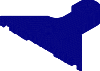

In [4]:
mid_x = 0.5 * (s.bbox_min[1] + s.bbox_max[1])
clipped = crop_plane(mesh, [mid_x, 0.0, 0.0], [-1.0, 0.0, 0.0]; mode=:any)
println("clipped points: ", num_points(clipped), " (from ", num_points(mesh), ")")
render(clipped)

## Element quality, as a chart instead of a colour

`attach_quality` writes each metric back as `cell_data`. We crop to a legible corner first (the full skin
is tens of thousands of facets), then show the distribution of `quality:scaled_jacobian` as a histogram —
the numeric analogue of the C++ notebook's colour-by-quality render.

corner: 772

 points, 2842 tetrahedra
quality:scaled_jacobian min=0.0823

 mean=0.4321 max=0.9842


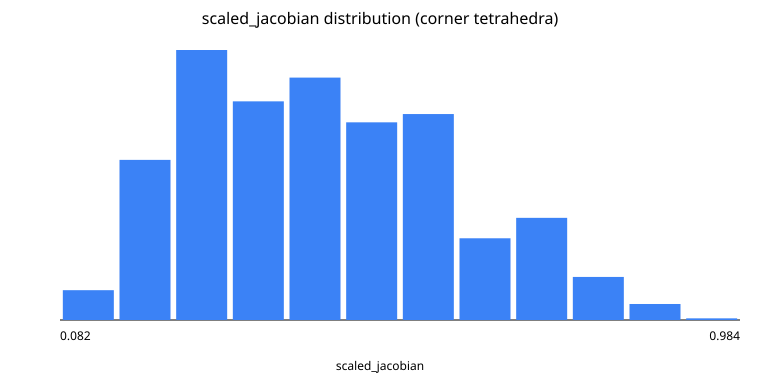

In [5]:
bbox_lo, bbox_hi = collect(s.bbox_min), collect(s.bbox_max)
corner_hi = bbox_lo .+ (bbox_hi .- bbox_lo) .* 0.4
corner = crop_bbox(mesh, bbox_lo, corner_hi)
annotated = attach_quality(corner)
tet_block = num_cell_blocks(annotated)
println("corner: ", num_points(annotated), " points, ", cell_block_info(annotated, tet_block).num_cells,
        " tetrahedra")

sj = vec(cell_data(annotated, "quality:scaled_jacobian", tet_block))
finite = filter(isfinite, sj)
println("quality:scaled_jacobian min=", round(minimum(finite); digits=4),
        " mean=", round(sum(finite)/length(finite); digits=4),
        " max=", round(maximum(finite); digits=4))

K = 12
edges = range(minimum(finite), maximum(finite); length=K + 1)
counts = zeros(Int, K)
for v in finite
    b = clamp(Int(floor((v - edges[1]) / (edges[end] - edges[1]) * K)) + 1, 1, K)
    counts[b] += 1
end
histogram_chart(collect(edges), counts, "scaled_jacobian distribution (corner tetrahedra)", "scaled_jacobian")

## A field, as a chart instead of a colour

The corner's height (`z`) is a signed quantity relative to the bracket's base — again shown as a histogram
rather than a diverging-colormap render, for the same flat-ABI reason.

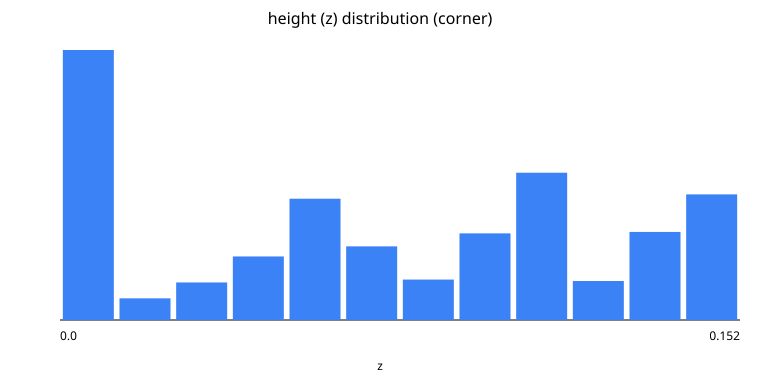

In [6]:
z = vec(points(corner))[3:3:end]
K = 12
edges = range(minimum(z), maximum(z); length=K + 1)
counts = zeros(Int, K)
for v in z
    b = clamp(Int(floor((v - edges[1]) / (edges[end] - edges[1]) * K)) + 1, 1, K)
    counts[b] += 1
end
histogram_chart(collect(edges), counts, "height (z) distribution (corner)", "z")

The same `--color-by NAME --colorbar` options are available on the command line and from the TikZ
writer, but only through the **full C++ CLI** — not through this flat-ABI binding.

That's the round trip: **meshio++'s C API reads the mesh** through the Julia binding, computes quality
metrics on it, and its own SVG writer renders it — no Python, no external rendering library. See
[`02_convert_and_inspect.ipynb`](./02_convert_and_inspect.ipynb) for converting the same mesh between
formats, and [`03_mesh_operations.ipynb`](./03_mesh_operations.ipynb) for the rest of the operations
layer.